## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

- Jeremy Liu: Conceptualization, Methodology, Writing, Project administration, Writing – original draft, Software
- Paul Nguyen: Analysis, Software, Visualization, Methodology, Writing, Background Research, Writing – original draft, Experimental investigation
- Xijian Xiang: Analysis, Software, Writing, Methodology, Background Research, Data Curation, Writing – original draft, Experimental investigation
- Renheng Huang: Analysis, Software, Visualization, Writing – review & editing, Experimental investigation
- Jenny Zhang: Analysis, Software, Visualization, Writing – review & editing, Experimental investigation

# Research Question

Does the relative wingspan (wingspan minus height) of an NBA player affect their overall performance? This project will focus on NBA seasons from 2018 to 2022. We select this five-season window because advanced metrics such as RAPTOR, LEBRON, DARKO, True Shooting and On-Off are consistently available during this period, and draft combine wingspan and current-season measurements can be matched to active NBA players. Restricting our analysis to 2018–2022 ensures metric consistency while maintaining a sufficiently large and recent sample. Our analysis will treat each player-season as one observation.

## Background and Prior Work

Prior research has examined the relationship between body proportions and athletic performance. Monson et al. (2018) find that variations in limb proportions are associated with elite athletic success, suggesting that longer wingspans may confer biomechanical advantages. Similarly, Kaazempur-Mofrad (2022) argues that longer wingspans enhance defensive potential in basketball while potentially hindering shooting efficiency. These findings imply that wingspan may have heterogeneous effects across offensive and defensive dimensions of performance.

However, existing literature primarily focuses on biomechanical mechanisms or isolated performance indicators. There has been limited examination of how wingspan relates to modern composite advanced metrics that integrate offensive and defensive contributions into single numerical estimates.

Most of the advanced metrics used in this study, such as RAPTOR, LEBRON, and DARKO, are composite metrics that combine both offensive and defensive components into a single numerical value. These metrics incorporate box score statistics, on/off impact, and regression-based modeling to estimate a player’s overall contribution. Since wingspan is believed to influence defensive actions such as shot contesting, deflections, and rim protection, we expect it to primarily affect the defensive components of these metrics. In contrast, True Shooting Percentage (TS%) measures scoring efficiency and does not directly incorporate defensive performance.

By examining relative wingspan in relation to advanced metrics during the 2018–2022 NBA seasons, our study extends prior research by evaluating whether the defensive advantages suggested in the literature translate into measurable effects within contemporary performance models.

We could not find studies detailing tracking different advanced metrics such as LEBRON, DARKO and RAPTOR and using wingspan to track any correlations in performance. 

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Kaazempur-Mofrad, A. (28 Dec 2022) Basketball Players' Long Wingspan Enhances Defensive Upside but Hinders Shooting Capabilities. *SportXIV*. https://sportrxiv.org/index.php/server/preprint/view/238/463
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Monson, T. et al. (Jul 2018) Allometric Variation in Modern Humans and the Relationship Between Body Proportions and Elite Athletic Success. *Journal of Anthropology of Sport and Physical Education* https://jaspe.ucg.ac.me/clanci/JASPE_July_2018_Monson_3-8.pdf
Journal of Anthropology of Sport and Physical Education*. https://jaspe.ucg.ac.me/clanci/JASPE_July_2018_Monson_3-8.pdf
3. <a name="cite_note-2"></a> [^](#cite_ref-3) Author Unknown. (Date Unknown) LEBRON: The man, the myth, the metric? *bball-index.com* https://www.bball-index.com/lebron-introduction/
4. ^ Medvedovsky, K. (Date Unknown) DARKO: Daily Plus-Minus NBA Player Impact Metric. https://apanalytics.shinyapps.io/DARKO/
5. ^ Silver, N. (2019) How Our RAPTOR Metric Works. FiveThirtyEight. https://fivethirtyeight.com/features/how-our-raptor-metric-works/

# Hypothesis


H1a: Relative wingspan is positively associated with defensive advanced metrics (e.g., Defensive RAPTOR, Defensive LEBRON, Defensive DARKO).

H1b: Relative wingspan is negatively associated with scoring efficiency and general offensive metrics (e.g., True Shooting Percentage, Offensive RAPTOR, Offensive LEBRON, Offensive DARKO).

H1c: Relative wingspan has a positive association with composite advanced metrics (e.g., overall RAPTOR, LEBRON, DARKO, On-Off), reflecting the net balance between defensive gains and potential offensive trade-offs.

H0: Relative wingspan has no statistically significant association with these performance metrics during the 2018–2022 NBA seasons.

We believe that there is evidence to suggest that wingspan may negatively affect offensive capabilities, but positively affect offensive capabilities, and that the net tips in favor of a positive correlation in performance overall, as evidenced by our sources. 

## Data

#### Note: All mentioned notebooks are in the Data directory.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata

In [2]:
#used for removing accents and special symbols
def remove_accents(name):
    if(isinstance(name, str)):
        return unicodedata.normalize('NFKD', name).encode('ascii', errors='ignore').decode('utf-8')
    else: return name

### RAPTOR Metric

https://www.nbarapm.com/datasets/MetricHistory (Click the "raptor" tab) (extracted by F12 Inspect Element, switch from tab "elements" to tab "network", turn on "Preserve Log", reload page if prompted, check for raptor.json, go to responses tab, copy .json file)

The dataset has RAPTOR metrics for thousands of players spanning multiple years. All of the raw data was stored in "data/00-raw/raptor_raw.json"
- There are 12500 entries and 13 variables
- The most important categories we have saved are raptor, raptor_offense, and raptor_defense, which is one of the advanced metrics we are interested in looking at.
- A raptor of 0 indicates a league-average player, a raptor-defense of 0 indicates league-average defensive capabilities, and a raptor-offense of 0 indicates league-average offensive capabilities.
- In terms of concerns for these specific metrics, not all players will have a RAPTOR score if they don't play enough. Major players like LeBron James and Stephen Curry have data compared to some benchwarmers who may only play a couple of minutes. We will get rid of players who don't play enough minutes in the final product.
- There were no major concerns regarding cleanliness or tidyness, as there was no missing data or values at all. Therefore, we did not have to drop any data. 

In [3]:
raptor=pd.read_json("data/00-raw/raptor_raw.json")
#check notebook read_json_datasets.ipynb in data/00-raw
#find cleaned raptor in data/01-interim
print(f"Size of this dataset:\n{raptor.shape}")
print(f"Possible Missing Data:\n{raptor.isna().sum()}")
raptor.head()

Size of this dataset:
(12500, 13)
Possible Missing Data:
d_raptor_rank     0
mp                0
nba_id            0
o_raptor_rank     0
player_id         0
player_name       0
poss              0
raptor_defense    0
raptor_offense    0
raptor_rank       0
raptor_total      0
season            0
war_total         0
dtype: int64


,d_raptor_rank,mp,nba_id,o_raptor_rank,player_id,player_name,poss,raptor_defense,raptor_offense,raptor_rank,raptor_total,season,war_total
0,131,959,abdelal01,220,abdelal01,Alaa Abdelnaby,1998,-0.2,-2.6,210,-2.8,1992,-0.006893
1,256,1379,abdelal01,225,abdelal01,Alaa Abdelnaby,2754,-2.1,-2.4,251,-4.4,1993,-1.227189
2,4,3483,abdulka01,1,abdulka01,Kareem Abdul-Jabbar,7674,3.1,4.5,1,7.6,1977,18.488255
3,3,2399,abdulka01,6,abdulka01,Kareem Abdul-Jabbar,5343,3.4,3.4,1,6.9,1978,11.688727
4,8,3524,abdulka01,10,abdulka01,Kareem Abdul-Jabbar,7826,2.5,3.0,1,5.5,1979,14.739138


We then cleaned the raw using "Cleaning_lebron_darko_raptor.ipynb", keeping only the 3 mentioned metrics alongside the player name for identification. We filtered the data into the 5 years based on the "Season" column, and saved these into 5 csv files for 2018-2022, which can be found in "01-interim/raptor_cleaned". We also made sure to rename the "player_name" column to "Player", and converted the names to lowercase and replaced any special accents and characters with their more standard versions, for merging purposes.

In [4]:
raptor_2022=pd.read_csv("data/01-interim/raptor_cleaned/raptor_2022.csv") 
#You can change the two :2022"s into any year from 2018-2022 to get the year's data
#example of csv for single-season raptor from 2022
print(raptor_2022.shape)
raptor_2022.head()

(331, 4)


,Player,raptor_total,raptor_defense,raptor_offense
0,nikola jokic,14.6,6.0,8.5
1,giannis antetokounmpo,8.1,2.5,5.6
2,joel embiid,7.8,4.2,3.6
3,rudy gobert,6.9,6.8,0.1
4,stephen curry,6.8,0.6,6.2


### LEBRON Metric

https://www.bball-index.com/lebron-application/ (Scroll down, click the "Player Data" tab, filter single season and download invidual csv for each year from 2018 to 2022 with the download button at bottom, 5 csv files total)

This dataset has LEBRON metrics for hundreds of players. We downloaded 5 different lebron CSV files for each season from 2018 to 2022, with the websites built-in ability to select stats from different seasons and then download their csvs. All of the raw data was stored in "data/00-raw/lebron_raw". To save space and time, we are only going to show the LEBRON dataset for 2022. 
- There were 423 entries in the csv file for lebron_2022. Each yearly dataset has ~400 entries. 
- The most important variables are LEBRON, O-LEBRON and D-LEBRON.
- A LEBRON of 0 represents an average player, and O-LEBRON and D-LEBRON scores of 0 represent league-average offensive and defensive capabilities, respectively.
- In terms of concerns for these specific metrics, not all players will have a RAPTOR score if they don't play enough. Major players like LeBron James and Stephen Curry have data compared to some benchwarmers who may only play a couple of minutes. We will get rid of players who don't play enough minutes in the final product.
- There were no major concerns regarding cleanliness or tidyness, as there was no missing data or values at all. Therefore, we did not have to drop any data. 

In [5]:
lebron_2022=pd.read_csv("data/00-raw/lebron_raw/lebron_2022.csv")
#the rest of the raw LEBRON data is in the path above
print(f"Size of this dataset:\n{lebron_2022.shape}")
print(f"Possible Missing Data:\n{lebron_2022.isna().sum()}")
#We have tested .isna().sum() on every raw lebron csv file in Cleaning_lebron_raptor_darko.ipynb(). 
#There were no NAN entries in any of the raw lebron files. 
lebron_2022.head()

Size of this dataset:
(423, 12)
Possible Missing Data:
nba_id      0
Player      0
Seasons     0
Team        0
Pos         0
MPG         0
LEBRON      0
O-LEBRON    0
D-LEBRON    0
WAR         0
OffRole     0
DefRole     0
dtype: int64


,nba_id,Player,Seasons,Team,Pos,MPG,LEBRON,O-LEBRON,D-LEBRON,WAR,OffRole,DefRole
0,2544,Lebron James,2022,LAL,C,37.220,3.342,3.612,-0.270,7.657,Shot Creator,Helper
1,2546,Carmelo Anthony,2022,LAL,PF,25.990,-2.231,-0.229,-2.003,0.193,Versatile Big,Helper
2,2730,Dwight Howard,2022,LAL,C,16.179,0.280,-0.791,1.071,1.673,Roll + Cut Big,Anchor Big
3,2738,Andre Iguodala,2022,GSW,SF,19.446,1.230,-0.246,1.475,1.408,Stationary Shooter,Helper
4,2772,Trevor Ariza,2022,LAL,SF,19.263,-1.446,-1.183,-0.263,0.281,Movement Shooter,Wing Stopper


We then cleaned the raw using "Cleaning_lebron_darko_raptor.ipynb", keeping only the 3 mentioned metrics alongside the player name for identification. We cleaned each raw csv, and saved these into 5 csv files for 2018-2022, which can be found in "01-interim/lebron_cleaned". We also converted the names to lowercase and replaced any special accents and characters with their more standard versions for merging purposes.

In [6]:
lebron_2022_cleaned=pd.read_csv("data/01-interim/lebron_cleaned/lebron_2022_cleaned.csv")
print(lebron_2022_cleaned.shape)
lebron_2022_cleaned.head() #the rest are in the specified file path above

(423, 4)


,Player,LEBRON,D-LEBRON,O-LEBRON
0,nikola jokic,7.045,1.796,5.249
1,giannis antetokounmpo,6.627,2.058,4.569
2,joel embiid,5.301,1.065,4.236
3,rudy gobert,4.513,3.434,1.079
4,stephen curry,4.467,0.732,3.735


### DARKO Metric

https://www.nbarapm.com/datasets/MetricHistory (Click the "raptor" tab) (extracted by F12 Inspect Element, switch from tab "elements" to tab "network", turn on "Preserve Log", reload page if prompted, check for DARKO.json, go to responses tab, copy .json file)

This dataset has DARKO metrics for thousands of players. All of the raw data was stored in "data/00-raw/darko_raw.json"
- This dataset has 15024 entries, and 16 categories. 
- The most important categories are darko (dpm), darko_defense (d_dpm) and darko_offense (o_dpm).
- A darko of 0 represents the average player. darko_defense and darko_offense represent average defensive and offensive capabilities, respectively.
- In terms of concerns for these specific metrics, not all players will have a RAPTOR score if they don't play enough. Major players like LeBron James and Stephen Curry have data compared to some benchwarmers who may only play a couple of minutes. We will get rid of players who don't play enough minutes in the final product.
- There were no major concerns regarding cleanliness or tidyness, as there was no missing data or values at all. Therefore, we did not have to drop any data. 

In [7]:
darko=pd.read_json("data/00-raw/darko_raw.json")
print(f"Size of this dataset:\n{darko.shape}")
print(f"Possible Missing Data:\n{darko.isna().sum()}")
darko.head()

Size of this dataset:
(15024, 16)
Possible Missing Data:
age            0
box_ddpm       0
box_odpm       0
d_dpm          0
d_dpm_rank     0
dpm            0
dpm_rank       0
nba_id         0
o_dpm          0
o_dpm_rank     0
on_off_ddpm    0
on_off_odpm    0
player_name    0
season         0
team_name      0
tm_id          0
dtype: int64


,age,box_ddpm,box_odpm,d_dpm,d_dpm_rank,dpm,dpm_rank,nba_id,o_dpm,o_dpm_rank,on_off_ddpm,on_off_odpm,player_name,season,team_name,tm_id
0,36.1,-0.35,1.49,-0.60,299,0.46,71,2,1.06,50,-1.08,-0.34,Byron Scott,1997,Los Angeles Lakers,1610612747
1,31.1,-0.17,-0.89,-0.14,162,-0.99,179,3,-0.85,206,-0.06,-0.65,Grant Long,1997,Detroit Pistons,1610612765
2,38.0,-0.49,-2.36,-0.47,256,-2.90,406,7,-2.43,388,-0.33,-3.06,Dan Schayes,1997,Orlando Magic,1610612753
3,35.7,-0.54,-1.44,-0.53,275,-2.02,302,9,-1.49,284,-0.44,-1.95,Sedale Threatt,1997,Houston Rockets,1610612745
4,27.3,-0.52,-1.22,-0.52,273,-1.72,263,12,-1.19,242,-0.57,-0.95,Chris King,1997,Miami Heat,1610612748


We then cleaned the raw using "Cleaning_lebron_darko_raptor.ipynb", keeping only the 3 mentioned metrics alongside the player name for identification. We filtered the data into the 5 years based on the "Season" column, and saved these into 5 csv files for 2018-2022, which can be found in "01-interim/raptor_cleaned". We also made sure to rename the "player_name" column to "Player", and converted the names to lowercase and replaced any special accents and characters with their more standard versions for merging purposes.

In [8]:
darko_2022=pd.read_csv("data/01-interim/darko_cleaned/darko_2022.csv")
#example for raptor_2022, wrangled in other notebook
print(darko_2022.shape)
darko_2022.head()

(633, 4)


,Player,dpm,d_dpm,o_dpm
0,giannis antetokounmpo,7.16,2.66,4.50
1,joel embiid,6.35,2.39,3.96
2,lebron james,5.54,0.55,4.99
3,nikola jokic,5.32,1.37,3.95
4,jayson tatum,5.24,0.65,4.59


### Wingspans and Length

##### All wingspan data was cleaned with v2 Wingspan Cleaner.ipynb in the data directory

https://chromewebstore.google.com/detail/instant-data-scraper/ofaokhiedipichpaobibbnahnkdoiiah (Google Chrome Extension Scraping Tool)

https://craftednba.com/player-traits/length (crafted_2026) (Scraped with the Chrome Extension Scraping Tool)

https://data.scorenetwork.org/basketball/nba_wingspans_and_performance.html (crafted_2025) (downloadable file)

https://www.kaggle.com/datasets/marcusfern/nba-draft-combine (wingspan_kaggle) (downloadable file)

https://www.nba.com/stats/draft/combine-anthro?SeasonYear=2002-03 (nbaorg wingspan measurements) (link is to 2002-03, took all years from 02-03 to 21-22, using scraping tool)

We have four datasets that are used to capture as many players in our 5-season timeframe as possible. Since official wingspans for this time period are not exactly aggregated on NBA.com, we look to find as many wingspans as possible and match them to the players in our datasets that wlll merge the data from the other 5 categories so that we can find a season summary. What is notable is the length/relative wingspan, which is the difference between the wingspan and height of the player. The average human's relative wingspan is about 0; in the NBA, there are many athletes who have major positive relative wingspans, and players with negative relative wingspans are a rarity. We are interested in finding the height and wingspan, which can be used to calculate the relative wingspan by subtracting height from wingspan. We used some chrome extensions to help scrape this data. The measurements are all in inches. 

In the crafted_2026 dataset, there were no NAN values, but our scraping tool made things look un-clean. We were able to reference the original source when it came to renaming columns.

Note that Crafted only keeps player measurements for the most recent NBA season. The Score Sports Data Repository credited crafted with providing the wingspan data, and this section was last updated in 2025; therefore, our dataset that was downloaded from SSDR was called crafted_2025. Also note that in the crafted_2025 dataset, relative wingspan is labeled "wingspan_advantage".In the crafted_2025 dataset, there were NAN values, but they were not in any of the relevant columns, so were able to drop the unneeded columns. 

In the kaggle set, there were very many NAN values, and in the nbaorg data, there were also many missing values, and our scraping also made the data look un-clean, but we were able to rename the columns correctly. 

How we cleaned each one will be detailed below.

In [9]:
crafted_2026=pd.read_csv("data/00-raw/Wingspan_Raw/wingspan_crafted_2026.csv")
crafted_2025=pd.read_csv("data/00-raw/Wingspan_Raw/wingspan_crafted_2025.csv")
wingspan_kaggle=pd.read_csv("data/00-raw/Wingspan_Raw/wingspan_Kaggle.csv")
two_three_frag=pd.read_csv("data/00-raw/Wingspan_Raw/wingspan_nbaorg/0203.csv")
#two_three_frag is an example fragment. We merged all of the fragments for every year into one big dataframe, and then we cleaned it.

In [10]:
print(f"Size of this dataset:\n{crafted_2026.shape}")
#columns are supposed to be [rank | name | team/position | height | wingspan | length (relative wingspan)]. You can check from the website link.
#we wrangled and corrected the column names. Can be found in 01-interim. 
print(f"Possible Missing Data:\n{crafted_2026.isna().sum()}")
crafted_2026.head()

Size of this dataset:
(427, 6)
Possible Missing Data:
the-rank                       0
the-name                       0
block                          0
tablescraper-selected-row      0
tablescraper-selected-row 2    0
tablescraper-selected-row 3    0
dtype: int64


,the-rank,the-name,block,tablescraper-selected-row,tablescraper-selected-row 2,tablescraper-selected-row 3
0,1,Mo Bamba,TOR | C,"6'11.25""","7'10""",10.75
1,2,Jalen Williams,OKC | SG,"6'4.5""","7'2.25""",9.75
2,3,Isaiah Stewart,DET | C,"6'7.25""","7'4.75""",9.50
3,4,Robert Williams III,POR | C,"6'8""","7'5.5""",9.50
4,5,Cedric Coward,MEM | SG,"6'5.25""","7'2.25""",9.00


In the crafted_2026 dataset, there were no NAN values, but our scraping tool made things look un-clean. We were able to reference the original source when it came to renaming columns.

In [11]:
print(f"Size of this dataset:\n{crafted_2025.shape}")
print(f"Possible Missing Data:\n{crafted_2025.isna().sum()}")
crafted_2025.head() #we wrangled and corrected the column names. Can be found in 01-interim. 

Size of this dataset:
(419, 26)
Possible Missing Data:
name                   0
team                   0
position               0
height_inches          0
wingspan_inches        0
wingspan_advantage     0
g                      1
mp                     1
pts                    1
orb                    1
drb                    1
trb                    1
ast                    1
stl                    1
blk                    1
o_rtg                  1
d_rtg                  1
e_fg_percent           1
ft_percent             8
fg_percent             1
avg_dist_of_fg         1
2pt_rate               1
3pt_rate               1
2pt_percent            1
3pt_percent           13
dunk_rate              1
dtype: int64


,name,team,position,height_inches,wingspan_inches,wingspan_advantage,g,mp,pts,orb,...,d_rtg,e_fg_percent,ft_percent,fg_percent,avg_dist_of_fg,2pt_rate,3pt_rate,2pt_percent,3pt_percent,dunk_rate
0,AJ Johnson,WAS,SG,76.25,80.50,4.25,29.0,639.0,16.4,0.6,...,123.0,0.441,0.865,0.385,12.0,0.577,0.423,0.472,0.267,0.099
1,Aaron Gordon,DEN,PF,79.50,83.75,4.25,51.0,1447.0,24.9,2.7,...,120.0,0.607,0.810,0.531,11.8,0.654,0.346,0.582,0.436,0.141
2,Aaron Holiday,HOU,PG,71.75,79.50,7.75,62.0,792.0,20.9,0.8,...,114.0,0.571,0.829,0.437,20.8,0.325,0.675,0.517,0.398,0.000
3,Aaron Nesmith,IND,SF,77.00,82.00,5.00,45.0,1123.0,23.2,1.6,...,116.0,0.617,0.913,0.507,15.7,0.485,0.515,0.587,0.431,0.042
4,Aaron Wiggins,OKC,SG,76.50,81.75,5.25,76.0,1744.0,25.2,2.2,...,110.0,0.577,0.831,0.488,14.2,0.534,0.466,0.578,0.383,0.027


In [12]:
print(f"Size of this dataset:\n{wingspan_kaggle.shape}")
#Most important columns are "PLAYER", "WNGSPN" (wingspan), "HGT" (height)
print(f"Possible Missing Data:\n{wingspan_kaggle.isna().sum()}")
#Many of the columns with missing values were irrelevant to our study, so we ended up dropping these columns before dropping missing values from
#the most important columns. 
wingspan_kaggle.head()

Size of this dataset:
(1678, 21)
Possible Missing Data:
YEAR           0
PLAYER         0
POS            1
HGT            4
WGT            5
BMI            5
BF           441
WNGSPN         3
STNDRCH        5
HANDL        733
HANDW        733
STNDVERT     189
LPVERT       189
LANE         198
SHUTTLE     1061
SPRINT       197
BENCH        604
BAR            4
PAN          733
PBHGT        190
PDHGT        190
dtype: int64


,YEAR,PLAYER,POS,HGT,WGT,BMI,BF,WNGSPN,STNDRCH,HANDL,...,STNDVERT,LPVERT,LANE,SHUTTLE,SPRINT,BENCH,BAR,PAN,PBHGT,PDHGT
0,2025,"Almansa, Izan",C,81.25,220.4,23.5,NaN,85.75,109.5,9.25,...,28.0,34.0,11.5,2.9,3.3,NaN,105.5%,87.9,137.5,143.5
1,2025,"Avdalas, Neoklis",SF,79.50,197.8,22.0,NaN,81.00,104.5,8.25,...,27.0,33.5,11.0,3.0,3.2,NaN,101.9%,80.9,131.5,138.0
2,2025,"Bailey, Ace",SF-PF,79.50,203.0,22.6,NaN,84.50,107.0,8.50,...,28.0,35.0,11.0,3.0,3.0,NaN,106.3%,76.5,135.0,142.0
3,2025,"Bates, Tamar",SG,75.75,191.0,23.4,NaN,82.25,103.0,9.75,...,28.0,34.0,11.0,3.0,3.0,NaN,108.6%,87.8,131.0,137.0
4,2025,"Brea, Koby",SG,77.75,202.0,23.5,NaN,77.25,101.5,8.50,...,28.0,34.0,11.0,3.0,3.0,NaN,99.4%,79.1,129.5,135.5


In [13]:
print(f"Size of this dataset:\n{two_three_frag.shape}")
print(f"Possible Missing Data:\n{two_three_frag.isna().sum()}")
#columns are supposed to be [Player | Position | Height | Standing Reach | Weight | Wingspan]. There are other columns the scraper omitted
#but they were unneeded
#Note that the data is inconsistent across different years. For example, more recent years have tracked body fat and hand-span, but they are not
#needed for any of our future analysis. 
two_three_frag.head() #we wrangled and corrected the column names. Can be found in 01-interim. 

Size of this dataset:
(82, 6)
Possible Missing Data:
Crom_text__NpR1_               0
Crom_text__NpR1_ 2             0
tablescraper-selected-row 4    0
tablescraper-selected-row 5    0
tablescraper-selected-row 6    0
tablescraper-selected-row 7    0
dtype: int64


,Crom_text__NpR1_,Crom_text__NpR1_ 2,tablescraper-selected-row 4,tablescraper-selected-row 5,tablescraper-selected-row 6,tablescraper-selected-row 7
0,Nene,PF,6' 9.25'',9' 1'',253.0,7' 4.5''
1,Robert Archibald,PF-C,6' 10'',9' 1.5'',250.0,6' 11.75''
2,Maurice Baker,PG,5' 11.75'',8' 0'',178.0,6' 4''
3,Matt Barnes,SF,6' 6.75'',8' 0.5'',226.0,6' 9''
4,Lubos Barton,SF-SG,6' 6.5'',8' 11'',221.0,7' 0''


#### Wingspan Cleaning
All of the Wingspan cleaning was performed in "v2 Wingspan Cleaner.ipynb"

For the crafted_2026 dataset, we started cleaning by dropping the irrelevant columns. We made sure to correctly convert the raw measurements, which included feet measurements, into total inches, rounding to 2 decimal points. We then dropped any entries with missing values. The columns we preserved were name, height_inches, wingpsan_inches and relative. We also converted the names to lowercase and replaced any special accents and characters with their more standard versions for merging purposes. Note that in the final result, there are no NAN values.

In [14]:
crafted_2026_cleaned=pd.read_csv("data/01-interim/wingspan_cleaned/wingspan_crafted_2026_cleaned.csv")
print(f"Size of this dataset:\n{crafted_2026_cleaned.shape}")
crafted_2026_cleaned.head()

Size of this dataset:
(427, 4)


,name,height_inches,wingspan_inches,relative
0,mo bamba,83.25,94.00,10.75
1,jalen williams,76.50,86.25,9.75
2,isaiah stewart,79.25,88.75,9.50
3,robert williams iii,80.00,89.50,9.50
4,cedric coward,77.25,86.25,9.00


For the crafted_2025 dataset, we started cleaning by dropping the irrelevant columns. We made sure to correctly convert the raw measurements, which included feet measurements, into total inches, rounding to 2 decimal points. We then dropped any entries with missing values. The The columns we preserved were name, height_inches, wingpsan_inches and relative (converted from "wingspan_advantage"). We also converted the names to lowercase and replaced any special accents and characters with their more standard versions for merging purposes. Note that in the final result, there are no NAN values.

In [15]:
crafted_2025_cleaned=pd.read_csv("data/01-interim/wingspan_cleaned/wingspan_crafted_2025_cleaned.csv")
print(crafted_2025_cleaned.shape)
print(crafted_2025_cleaned.isna().sum())
crafted_2025_cleaned.head()

(419, 4)
name               0
height_inches      0
wingspan_inches    0
relative           0
dtype: int64


,name,height_inches,wingspan_inches,relative
0,aj johnson,76.25,80.50,4.25
1,aaron gordon,79.50,83.75,4.25
2,aaron holiday,71.75,79.50,7.75
3,aaron nesmith,77.00,82.00,5.00
4,aaron wiggins,76.50,81.75,5.25


For the Kaggle dataset, we started cleaning by dropping the irrelevant columns. The raw measurements were already converted to full inches, and so we created a new column for the relative wingspan, that was the result of subtracting the height from the wingspan. We then dropped any entries with missing values. The columns we preserved were name, height_inches, wingpsan_inches and relative. We also converted the names to lowercase and replaced any special accents and characters with their more standard versions for merging purposes. Note that in the final result, there are no NAN values.

In [16]:
Kaggle_cleaned=pd.read_csv("data/01-interim/wingspan_cleaned/wingspan_Kaggle_cleaned.csv")
print(Kaggle_cleaned.shape)
print(Kaggle_cleaned.isna().sum())
Kaggle_cleaned.head()

(1674, 4)
name               0
height_inches      0
wingspan_inches    0
relative           0
dtype: int64


,name,height_inches,wingspan_inches,relative
0,izan almansa,81.25,85.75,4.5
1,neoklis avdalas,79.50,81.00,1.5
2,ace bailey,79.50,84.50,5.0
3,tamar bates,75.75,82.25,6.5
4,koby brea,77.75,77.25,-0.5


For the nbaorg dataset, we started cleaning by concatenating all of the single-year dataframes into one big dataframe. We then dropped the irrelevant columns. The raw measurements were converted to full inches, and so we then created a new column for the relative wingspan, that was the result of subtracting the height from the wingspan. We then dropped any entries with missing values. The columns we preserved were name, height_inches, wingpsan_inches and relative. We also converted the names to lowercase and replaced any special accents and characters with their more standard versions for merging purposes. Note that in the final result, there are no NAN values.

In [17]:
nbaorg_cleaned=pd.read_csv("data/01-interim/wingspan_cleaned/wingspan_nbaorg_combined.csv")
print(nbaorg_cleaned.shape)
print(nbaorg_cleaned.isna().sum())
nbaorg_cleaned.head()

(1149, 4)
name               0
height_inches      0
wingspan_inches    0
relative           0
dtype: int64


,name,height_inches,wingspan_inches,relative
0,kenny adeleke,78.50,82.25,3.75
1,maurice ager,75.25,79.75,4.50
2,lamarcus aldridge,82.00,88.75,6.75
3,morris almond,76.75,82.00,5.25
4,lou amundson,79.20,83.50,4.30


Finally, we concatenated all of the cleaned datasets into one big dataset. Since all of the columns names and measurement types were all standardized, this concatenation was able to keep all of our data, and the process was extremely clean. There were bound to be duplicates, as there was definitely player turnover from 2025 to 2026, which was measured in the two crafted datasets, so we concatenated based on reliability; we deemed the two crafted datasets to be more reliable, then the official draft anthro measurements from NBA.com, and then the measurements from Kaggle. Finally, we dropped duplicates, to get our final wingspan dataset. 

In [18]:
merged_wingspan_data=pd.read_csv("data/01-interim/wingspan_cleaned/combined_cleaned.csv")
print(merged_wingspan_data.shape)
#As you can see, there are way more entries than from each individual dataset, but not a clean sum, as there were some duplicates. 
merged_wingspan_data.head()

(1911, 4)


,name,height_inches,wingspan_inches,relative
0,kenny adeleke,78.50,82.25,3.75
1,maurice ager,75.25,79.75,4.50
2,lamarcus aldridge,82.00,88.75,6.75
3,morris almond,76.75,82.00,5.25
4,lou amundson,79.20,83.50,4.30


### True Shooting
https://www.basketball-reference.com/leagues/NBA_2022_advanced.html (Use the download as CSV feature. You can change the year by clicking on the link that leads to the previous or next year.)

Technically, these datasets are called "(Season) NBA Player Stats: Advanced". (Ex. 2021-22 NBA Player Stats: Advanced). These datasets have many different advanced basketball stats, such as PER, VORP, BPM, etc. The only stat we were interested in taking was TS. We downloaded 5 different Advanced Stats CSV files from basketball reference for each season from 2018 to 2022, with the websites built-in ability to select stats from different seasons and then download their CSV files. All of the raw data was stored in "data/00-raw/TS-raw". To save space and time, we are only going to show the True Shooting dataset for 2022. 
  - observations: 813
  - variables: 30
  - most relevant variables:
     - TS%: True Shooting Percentage. This measures the shooting efficiency in 2-points field goal, 3-points field goal, and free throws. This percentage equals to "points scored" divided by "shooting attempts", where the "shooting attempts" is calculated with special formula. For example, when TS%=50, it means this player has made higher score compared to other players who made the same amount of shooting attempts with TS%=30.

### LEBRON Metric

https://www.bball-index.com/lebron-application/ (Scroll down, click the "Player Data" tab, filter single season and download invidual csv for each year from 2018 to 2022 with the download button at bottom, 5 csv files total)

This dataset has LEBRON metrics for hundreds of players. We downloaded 5 different lebron CSV files for each season from 2018 to 2022, with the websites built-in ability to select stats from different seasons and then download their CSV files. All of the raw data was stored in "data/00-raw/lebron_raw". To save space and time, we are only going to show the LEBRON dataset for 2022. 
- There were 423 entries in the csv file for lebron_2022. Each yearly dataset has ~400 entries. 
- The most important variables are LEBRON, O-LEBRON and D-LEBRON.
- A LEBRON of 0 represents an average player, and O-LEBRON and D-LEBRON scores of 0 represent league-average offensive and defensive capabilities, respectively.
- In terms of concerns for these specific metrics, not all players will have a RAPTOR score if they don't play enough. Major players like LeBron James and Stephen Curry have data compared to some benchwarmers who may only play a couple of minutes. We will get rid of players who don't play enough minutes in the final product.
- There were no major concerns regarding cleanliness or tidyness, as there was no missing data or values at all. Therefore, we did not have to drop any data. 

In [19]:
raw_TS2022 = pd.read_csv("data/00-raw/TS_datas/TS-2022.csv")
print(f"Columns: {raw_TS2022.columns}")
print(f"Duplicated rows: {raw_TS2022.duplicated().sum()}")
print(f"Size of this dataset:\n{raw_TS2022.shape}")
print(f"Possible Missing Data:\n{raw_TS2022.isna().sum()}")
raw_TS2022.head(5)

Columns: Index(['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'PER', 'TS%',
       '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%', 'STL%', 'BLK%', 'TOV%',
       'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM', 'DBPM', 'BPM', 'VORP',
       'Awards', 'Player-additional'],
      dtype='object')
Duplicated rows: 0
Size of this dataset:
(813, 30)
Possible Missing Data:
Rk                     1
Player                 0
Age                    1
Team                   1
Pos                    1
G                      1
GS                     1
MP                     1
PER                    1
TS%                   13
3PAr                  15
FTr                   15
ORB%                   0
DRB%                   0
TRB%                   0
AST%                   0
STL%                   0
BLK%                   0
TOV%                  13
USG%                   0
OWS                    1
DWS                    1
WS                     1
WS/48                  1
OBPM                   1
DB

,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Awards,Player-additional
0,1.0,Mikal Bridges,25.0,PHO,SF,82.0,82.0,2854.0,14.4,0.627,...,5.2,3.7,8.9,0.150,0.5,1.1,1.6,2.6,DPOY-2DEF1,bridgmi01
1,2.0,Miles Bridges,23.0,CHO,PF,80.0,80.0,2837.0,17.9,0.593,...,5.0,2.3,7.2,0.123,1.8,-0.3,1.5,2.5,NaN,bridgmi02
2,3.0,DeMar DeRozan,32.0,CHI,PF,76.0,76.0,2743.0,23.1,0.590,...,7.0,1.8,8.8,0.154,3.4,-0.9,2.5,3.1,MVP-10ASNBA2,derozde01
3,4.0,Jayson Tatum,23.0,BOS,SF,76.0,76.0,2731.0,21.8,0.578,...,5.0,4.6,9.6,0.169,4.3,0.6,5.0,4.8,MVP-6ASNBA1,tatumja01
4,5.0,Saddiq Bey,22.0,DET,SF,82.0,82.0,2704.0,14.0,0.529,...,2.4,1.6,4.0,0.071,0.9,-1.2,-0.3,1.2,NaN,beysa01


#### Tidy: True  
- Columns: The columns of the dataset don't have any confusing variable names, and every column represents one variable. Although many of them are shortcuts of some words, the definition or meaning would be explained in the original dataset website.
- Rows: There are no duplicated rows. Each row is a observation, which contains player's name, age, and other stats. However, some Player names are repeated, always consecutively, and this is because BasketballReference keeps track of how Players play with different teams if they are traded or signed mid-season after being waived. We will drop duplicates later because a Player's first entry is their season aggregate. 
- Rows: There may be multiple rows for a single player. This is because this player played for different teams, and each rows would only show the data respect to a specific team. Unless the the "Team" column shows a "2TM", "3TM", etc, this is the overall data of this player. It combines all the data of the player from different teams.

### C.Size & D. Missing Values

In [20]:
print(f"size of this dataset:{raw_TS2022.shape}")

raw_TS2022_missing = raw_TS2022[raw_TS2022.isna().any(axis=1)]
raw_TS2022_missing_col = raw_TS2022.isna().any(axis=0)
a1,b1 = raw_TS2022_missing.shape
print(f"rows with missing data:{a1}")
raw_TS2022_missing.head()

size of this dataset:(813, 30)
rows with missing data:758


,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Awards,Player-additional
1,2.0,Miles Bridges,23.0,CHO,PF,80.0,80.0,2837.0,17.9,0.593,...,5.0,2.3,7.2,0.123,1.8,-0.3,1.5,2.5,NaN,bridgmi02
4,5.0,Saddiq Bey,22.0,DET,SF,82.0,82.0,2704.0,14.0,0.529,...,2.4,1.6,4.0,0.071,0.9,-1.2,-0.3,1.2,NaN,beysa01
5,6.0,Tyrese Haliburton,21.0,2TM,PG,77.0,77.0,2695.0,18.2,0.595,...,5.2,1.8,7.0,0.125,2.7,-0.1,2.6,3.1,NaN,halibty01
6,6.0,Tyrese Haliburton,21.0,SAC,SG,51.0,51.0,1757.0,17.0,0.575,...,2.7,1.2,4.0,0.109,2.2,0.4,2.6,2.0,NaN,halibty01
7,6.0,Tyrese Haliburton,21.0,IND,PG,26.0,26.0,938.0,20.5,0.629,...,2.5,0.6,3.0,0.156,3.8,-1.0,2.8,1.1,NaN,halibty01


There are missing values in multiple columns, this is reasonable because some players's data may be hard to find, or they have not have enough data. Most of the rows have missing values. This is because only a few players have awards, and the rest would have "NaN" in the Awards column.

### E.Outlier

In [21]:
TS_cols = ['TS%']
TS_Q1 = raw_TS2022[TS_cols].quantile(0.25)
TS_Q3 = raw_TS2022[TS_cols].quantile(0.75)
TS_range = TS_Q3 - TS_Q1
TS_outlier = (
    (raw_TS2022[TS_cols] < (TS_Q1 - 1.5*TS_range)) | (raw_TS2022[TS_cols] > (TS_Q3 + 1.5*TS_range))
).any(axis=0)
print(TS_outlier)
TS_outlier_row = raw_TS2022[ (raw_TS2022["TS%"] < TS_Q1["TS%"] - 1.5*TS_range["TS%"]) |
                                (raw_TS2022["TS%"] > TS_Q3["TS%"] + 1.5*TS_range["TS%"])]
TS_outlier_row

TS%    True
dtype: bool


,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Awards,Player-additional
146,125.0,Robert Williams,24.0,BOS,C,61.0,61.0,1804.0,22.1,0.745,...,6.0,3.9,9.9,0.262,2.4,3.1,5.5,3.4,DPOY-7DEF2,williro04
363,296.0,Tomáš Satoranský,30.0,SAS,SF,1.0,0.0,9.0,12.8,0.852,...,0.0,0.0,0.0,0.200,0.8,-2.1,-1.3,0.0,NaN,satorto01
424,329.0,Danuel House Jr.,28.0,NYK,SF,1.0,0.0,3.0,-13.4,0.000,...,0.0,0.0,0.0,-0.342,-12.6,-7.8,-20.4,0.0,NaN,houseda01
495,385.0,Kelan Martin,26.0,BOS,SF,3.0,0.0,6.0,-11.3,0.000,...,-0.1,0.0,0.0,-0.382,-14.7,-10.5,-25.1,0.0,NaN,martike03
498,387.0,Juancho Hernangómez,26.0,BOS,PF,18.0,0.0,96.0,3.8,0.307,...,-0.3,0.2,-0.1,-0.050,-6.9,-1.4,-8.3,-0.2,NaN,hernaju01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
801,595.0,Nate Hinton,22.0,IND,SG,2.0,0.0,2.0,-45.2,0.000,...,-0.1,0.0,-0.1,-1.231,-28.1,-14.5,-42.6,0.0,NaN,hintona01
802,596.0,David Johnson,20.0,TOR,SG,2.0,0.0,2.0,-20.0,0.000,...,0.0,0.0,0.0,-0.495,-19.0,-8.7,-27.7,0.0,NaN,johnsda08
805,599.0,Joe Johnson,40.0,BOS,SG,1.0,0.0,2.0,38.7,1.000,...,0.0,0.0,0.0,0.335,12.1,2.8,15.0,0.0,NaN,johnsjo02
807,601.0,Matt Mooney,25.0,NYK,SG,1.0,0.0,2.0,-20.0,0.000,...,-0.1,0.0,0.0,-0.915,-33.9,11.5,-22.3,0.0,NaN,moonema01


TS% has multiple outliers. From these outliers, we can see that some players have better performance than most of others, and some players have worse performance than most of others.

### F.Clean data

In [22]:
ts_2022=pd.read_csv("data/00-raw/TS_datas/TS-2022.csv")
ts_2022=ts_2022.reset_index(drop=True)
ts_needed=["Player","TS%"]
ts_2022=ts_2022[ts_needed]
ts_2022=ts_2022.drop_duplicates("Player")
ts_2022["Player"]=ts_2022["Player"].apply(remove_accents)
ts_2022["Player"]=ts_2022["Player"].str.lower()
#ts_2022.to_csv("data/01-interim/TS_cleaned/ts_2022_clean.csv", index=False)
ts_2022.head()

,Player,TS%
0,mikal bridges,0.627
1,miles bridges,0.593
2,demar derozan,0.590
3,jayson tatum,0.578
4,saddiq bey,0.529


### On-Off
  - Name: on-off-2022.csv
  - https://www.basketball-reference.com/leagues/NBA_2022_play-by-play.html
  - observations: 813
  - variables: 26
  - most relevant variables:
     - On-Off: This measures the team performance when the player is on the court versus off the court. It can be positive or negative. The larger this number is, the more positive impact a player can bring to the team, while the smaller number suggests the opposite.
     - G: Games. This is the amount of games a player has played in this season. A high number means that this player has played many matches in this season. For example, G=80 means this player has played 80 matches during the season, max of 82
     - MP: Minutes Played. This measures how much a player has played in the season in minutes. A high number means that this player has played many matches in this season. For example, MP=300 means this player has played for 300 minutes in this season. This variable may be useful in further analysis. 

In [23]:
raw_OF2022 = pd.read_csv("data/00-raw/OF_datas/on-off-2022.csv")

In [24]:
#fixing orientation
raw_OF2022.columns = raw_OF2022.iloc[0]
raw_OF2022=raw_OF2022[1:]

In [25]:
#tidy test
print(f"Duplicated rows: {raw_OF2022.duplicated().sum()}")
raw_OF2022.head(5)

Duplicated rows: 0


,Rk,Player,Age,Team,Pos,G,GS,MP,PG%,SG%,...,LostBall,Shoot,Off.,Shoot,Off.,PGA,And1,Blkd,Awards,-9999
1,1,Mikal Bridges,25,PHO,SF,82,82,2854,0,8,...,17,64,5,85,18,437,29,29,DPOY-2DEF1,bridgmi01
2,2,Miles Bridges,23,CHO,PF,80,80,2837,0,0,...,40,90,19,161,18,754,38,62,NaN,bridgmi02
3,3,DeMar DeRozan,32,CHI,PF,76,76,2743,0,0,...,61,89,18,287,12,948,74,84,MVP-10ASNBA2,derozde01
4,4,Jayson Tatum,23,BOS,SF,76,76,2731,0,1,...,71,66,32,186,10,833,41,81,MVP-6ASNBA1,tatumja01
5,5,Saddiq Bey,22,DET,SF,82,82,2704,0,7,...,14,44,18,117,5,561,26,52,NaN,beysa01


#### Tidy: False
- Rows: There are no duplicated rows. Each row is a observation, which contains player's name, age, and other stats. However, some Player names are repeated, always consecutively, and this is because BasketballReference keeps track of how Players play with different teams if they are traded or signed mid-season after being waived. We will drop duplicates later because a Player's first entry is their season aggregate. 

### C. Size & D. Missing values

In [26]:
print(f"size of this dataset:{raw_OF2022.shape}")

raw_OF2022_missing = raw_OF2022[raw_OF2022.isna().any(axis=1)]
raw_OF2022_missing_col = raw_OF2022.isna().any(axis=0)
a2,b2 = raw_OF2022_missing.shape
print(f"rows with missing data: {a2}")
raw_OF2022_missing.head()

size of this dataset:(812, 26)
rows with missing data: 757


,Rk,Player,Age,Team,Pos,G,GS,MP,PG%,SG%,...,LostBall,Shoot,Off.,Shoot,Off.,PGA,And1,Blkd,Awards,-9999
2,2,Miles Bridges,23,CHO,PF,80,80,2837,0,0,...,40,90,19,161,18,754,38,62,NaN,bridgmi02
5,5,Saddiq Bey,22,DET,SF,82,82,2704,0,7,...,14,44,18,117,5,561,26,52,NaN,beysa01
6,6,Tyrese Haliburton,21,2TM,PG,77,77,2695,33,63,...,34,52,9,81,11,1479,18,36,NaN,halibty01
7,6,Tyrese Haliburton,21,SAC,SG,51,51,1757,18,78,...,17,29,6,43,4,882,13,26,NaN,halibty01
8,6,Tyrese Haliburton,21,IND,PG,26,26,938,62,35,...,17,23,3,38,7,597,5,10,NaN,halibty01


In [27]:
raw_OF2022_missing_col

0
Rk          False
Player      False
Age         False
Team        False
Pos         False
G           False
GS          False
MP          False
PG%         False
SG%         False
SF%         False
PF%         False
C%          False
OnCourt     False
On-Off      False
BadPass     False
LostBall    False
Shoot       False
Off.        False
Shoot       False
Off.        False
PGA         False
And1        False
Blkd        False
Awards       True
-9999       False
dtype: bool

The only column that has missing data is the "Awards" column. Same as TS, only a few players received awards, so most rows would have missing value in this column.

### E.Outlier

In [28]:
OF_cols = ['On-Off', 'G', 'MP']
OF2022 = raw_OF2022.copy()
OF2022[OF_cols] = OF2022[OF_cols].apply(pd.to_numeric, errors='coerce')
OF_Q1 = OF2022[OF_cols].quantile(0.25)
OF_Q3 = OF2022[OF_cols].quantile(0.75)
OF_range = OF_Q3 - OF_Q1
OF_outlier = ((OF2022[OF_cols] < (OF_Q1 - 1.5 * OF_range)) | (OF2022[OF_cols] > (OF_Q3 + 1.5 * OF_range))).any(axis=0)
print(OF_outlier)
OF_outlier_row = OF2022[((OF2022[OF_cols] < (OF_Q1 - 1.5 * OF_range)) |(OF2022[OF_cols] > (OF_Q3 + 1.5 * OF_range))).any(axis=1)]
OF_outlier_row[OF_cols]

0
On-Off     True
G         False
MP        False
dtype: bool


,On-Off,G,MP
496,-72.4,3,6
499,-25.7,18,96
505,-38.0,14,112
531,98.7,1,1
551,32.0,1,27
...,...,...,...
806,-132.8,1,2
807,-132.8,1,2
808,-90.3,1,2
809,104.1,1,1


Columns G and MP don't have any outlier. For On-Off, these outliers represent the players who can greatly affect team performance. Very high value (positive) or very low value (negative) means they can bring a huge impact to the team when they are on the court. We can see that the very large and small On-Offs often correlate with players with extremely small sample-sizes of Games and Minutes Played. 

### F.Clean data

In [29]:
#generating clean copy of dataframe from csv for cleaning
#This is what we did in "Clean_OF_TS.ipynb"
of_2022=pd.read_csv("data/00-raw/OF_datas/on-off-2022.csv")
of_needed=["Player","G","MP","On-Off"]
of_2022.columns = of_2022.iloc[0]
of_2022=of_2022[1:]  
of_2022=of_2022.reset_index(drop=True)
of_2022=of_2022[of_needed]
of_2022=of_2022.drop_duplicates("Player")
of_2022["Player"]=of_2022["Player"].apply(remove_accents)
#Removed accents for easier merging
of_2022["Player"]=of_2022["Player"].str.lower()
#of_2022.to_csv("data/01-interim/on_off_cleaned/of_2022_clean.csv", index=False)
of_2022.head()

,Player,G,MP,On-Off
0,mikal bridges,82,2854,9.5
1,miles bridges,80,2837,5.8
2,demar derozan,76,2743,5.1
3,jayson tatum,76,2731,13.8
4,saddiq bey,82,2704,-4.7


### Complete Data Source

We have a complete data source where we merged our different data from each of the 5 seasons, which were in turn created by merging all of the relevant statistics for each year by player. It has the players, total number of games played in the season, total minutes, the LEBRON variations, DARKO variations, RAPTOR variations, TS and On-Off, as well as height, wingspan and relative wingspan. This final csv table was created in "Final_Data_Generator.ipynb". First, we loaded all of the cleaned datasets for every metric. We then merged each dataset based on the season, using on="Player", and each season was the result of merging 5 different datasets, specifically the LEBRON, RAPTOR, DARKO, TS and On-Off. We then added a Season column that was just the season, for each final year dataset. We then concatenated the 2018-2022 final datasets into one big dataset. We then merged the wingspan dataset after renaming the "name" column in the final wingspan dataset to "Player", and merged on "Player". Our rationale was that we were going to treat every season's result for one player as one data entry. For example, we chose to view LeBron's 2018 and 2019 seasons as different data entries despite being produced from the same person. Furthermore, a player's wingspan, height and relative wingspan are not subject to change year over year, so we decided to merge the wingspans after merging the aggregate data from the different seasons. Our final result definitely does not have as many values as total players, because not every player has had all of their LEBRON, DARKO, RAPTOR, TS and On-Off tracked. Lastly, there may be inconsistencies between names, for example, jimmy butler and jimmy butler iii are both used to represent the same individual, and we were not able to find a way to smooth out these inconsistencies. Merging upon 6 variables was bound to lead to disappearing entries. As a result, there are only about ~1200 viable data entries in the final dataset. 

In [30]:
final_result=pd.read_csv("data/02-processed/final_data.csv")
final_result

,Player,G,MP,On-Off,TS%,LEBRON,D-LEBRON,O-LEBRON,dpm,d_dpm,o_dpm,raptor_total,raptor_defense,raptor_offense,Season,height_inches,wingspan_inches,relative
0,mikal bridges,82,2854,9.5,0.627,1.376,1.181,0.195,1.21,0.22,0.99,2.7,0.9,1.8,2022,77.75,85.00,7.25
1,miles bridges,80,2837,5.8,0.593,0.797,-0.597,1.393,1.13,-0.28,1.40,1.7,-0.0,1.7,2022,77.25,81.50,4.25
2,demar derozan,76,2743,5.1,0.590,1.265,-1.530,2.794,0.40,-1.23,1.63,1.4,-2.3,3.6,2022,77.50,81.00,3.50
3,jayson tatum,76,2731,13.8,0.578,4.327,0.993,3.334,5.24,0.65,4.59,5.6,1.6,4.0,2022,79.50,83.00,3.50
4,saddiq bey,82,2704,-4.7,0.529,-2.045,-2.011,-0.034,-1.67,-1.25,-0.42,-2.3,-2.4,0.1,2022,79.00,83.00,4.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,shane larkin,54,775,-2.6,0.491,-1.276,-0.008,-1.268,-1.30,0.25,-1.55,-0.1,1.6,-1.7,2018,70.25,70.75,0.50
1251,terrance ferguson,61,763,-12.7,0.545,-3.014,-1.176,-1.837,-1.29,-0.07,-1.22,-4.5,-2.6,-1.9,2018,77.50,80.75,3.25
1252,nene,52,758,9.6,0.594,0.519,1.249,-0.730,1.90,2.99,-1.09,2.9,4.4,-1.5,2018,81.25,88.50,7.25
1253,richaun holmes,48,746,-7.0,0.585,-0.227,0.006,-0.233,-0.05,0.51,-0.56,-2.0,-0.1,-1.8,2018,80.25,85.50,5.25


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



In [31]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

### EDA Timeline

The variables we are interested in taking a look at are On-Off, TS%, LEBRON, D-LEBRON, O-LEBRON, dpm, d_dpm, o_dpm, raptor_total, raptor_defense, raptor_offense and relative.

**Data Introduction**
- We will run a basic description of our variables of interest which will show the mean, standard deviation, minimum, maximum, 25th percentile, 50th percentile/median, and 75th percentile for each. This will help show basic distributions and spread.

**Graphs and Visualization** 
- We will provide a histogram for each of the important variables in our dataset, which will be the On-Off, TS%, LEBRON, D-LEBRON, O-LEBRON, dpm, d_dpm, o_dpm, raptor_total, raptor_defense, raptor_offense and relative. This can help us see the shape, skew, frequency distribution and spread of the data, as well as identify outliers.
- We will then provide a pairplot between relative and all of the other listed variables to see the shape of our data. This will allow us to see the pairwise relationship between relative and all of the other variables, and identify possible correlation and trends, as well as clusters and different patterns. 
- We will then provide a scatterplot between relative and all of the other listed variables to provide more context. It will be similar to the pairplots, but it will also allow us to better understand the regression by providing lines of best fit. 

**Data Models and Analysis**
- We will (potentially) run our variables through different correlation tests. Since we are comparing continuous data to continuous data, we will take a look at both Spearman and Pearson correlations. The Spearman correlation is used to analyse the strength and direction of a monotonic relationship (essentially covers a relationship that might not be linear), even when the data is non-normal and may contain outliers, while the Pearson correlation is used to measure the strength and direction of a relationship, although this is strictly linear. 
- We will finish by running an OLS (Ordinary Least Squares) on our data. This will help create a line of best-fit and return other important information, such as p-values, to see if our data is statistically significant, regression coefficients ,and the r<sup>2</sup> coefficient of determination that explains the variation in the data.
- Maybe PCA regression

**Lastly, we will interpret our findings.**

#### Data Introduction - Basic Overview

Let's take a general look at our data. As we can see, overall LEBRON, DARKO and RAPTOR have a mean and median very close to 0. The average True Shooting Percentage during this time is around 0.57. The On-Off centers around 0.7. Lastly, the relative is about 4.75 inches. 

In [32]:
final_result=pd.read_csv("data/02-processed/final_data.csv")
final_result.describe()

,G,MP,On-Off,TS%,LEBRON,D-LEBRON,O-LEBRON,dpm,d_dpm,o_dpm,raptor_total,raptor_defense,raptor_offense,Season,height_inches,wingspan_inches,relative
count,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000,1255.000000
mean,62.977689,1638.756972,0.761912,0.567698,0.128753,0.078383,0.050357,0.229857,0.130191,0.099745,0.237211,0.133466,0.104462,2020.090837,77.880279,82.663147,4.782869
std,12.122756,537.325782,5.408213,0.047777,1.879314,1.144543,1.581064,1.945312,1.142882,1.623011,2.909045,1.887560,2.259355,1.423107,3.286275,3.925064,2.266325
min,21.000000,418.000000,-18.500000,0.421000,-4.584000,-3.464000,-3.748000,-5.570000,-3.680000,-3.130000,-8.400000,-5.800000,-5.700000,2018.000000,68.750000,70.750000,-1.500000
25%,55.000000,1205.500000,-2.600000,0.536000,-1.152500,-0.694500,-1.017500,-1.095000,-0.680000,-0.980000,-1.700000,-1.100000,-1.400000,2019.000000,75.625000,79.750000,3.250000
50%,64.000000,1622.000000,0.600000,0.565000,-0.037000,0.037000,-0.170000,-0.080000,0.010000,-0.210000,0.100000,0.000000,-0.100000,2020.000000,78.000000,82.750000,4.750000
75%,72.000000,2041.500000,4.200000,0.597000,1.140500,0.876000,0.787500,1.170000,0.885000,0.700000,2.000000,1.400000,1.200000,2021.000000,80.250000,85.500000,6.500000
max,82.000000,3028.000000,19.100000,0.736000,8.291000,4.254000,6.895000,7.310000,4.490000,6.390000,14.600000,7.900000,9.600000,2022.000000,86.500000,94.000000,10.750000


#### Graphs and Visualizations - What does it look like?

We will first show histograms, pairplots, and lastly, scatterplots, for our relevant variables.

##### Histograms

(0.0, 1.0, 0.0, 1.0)

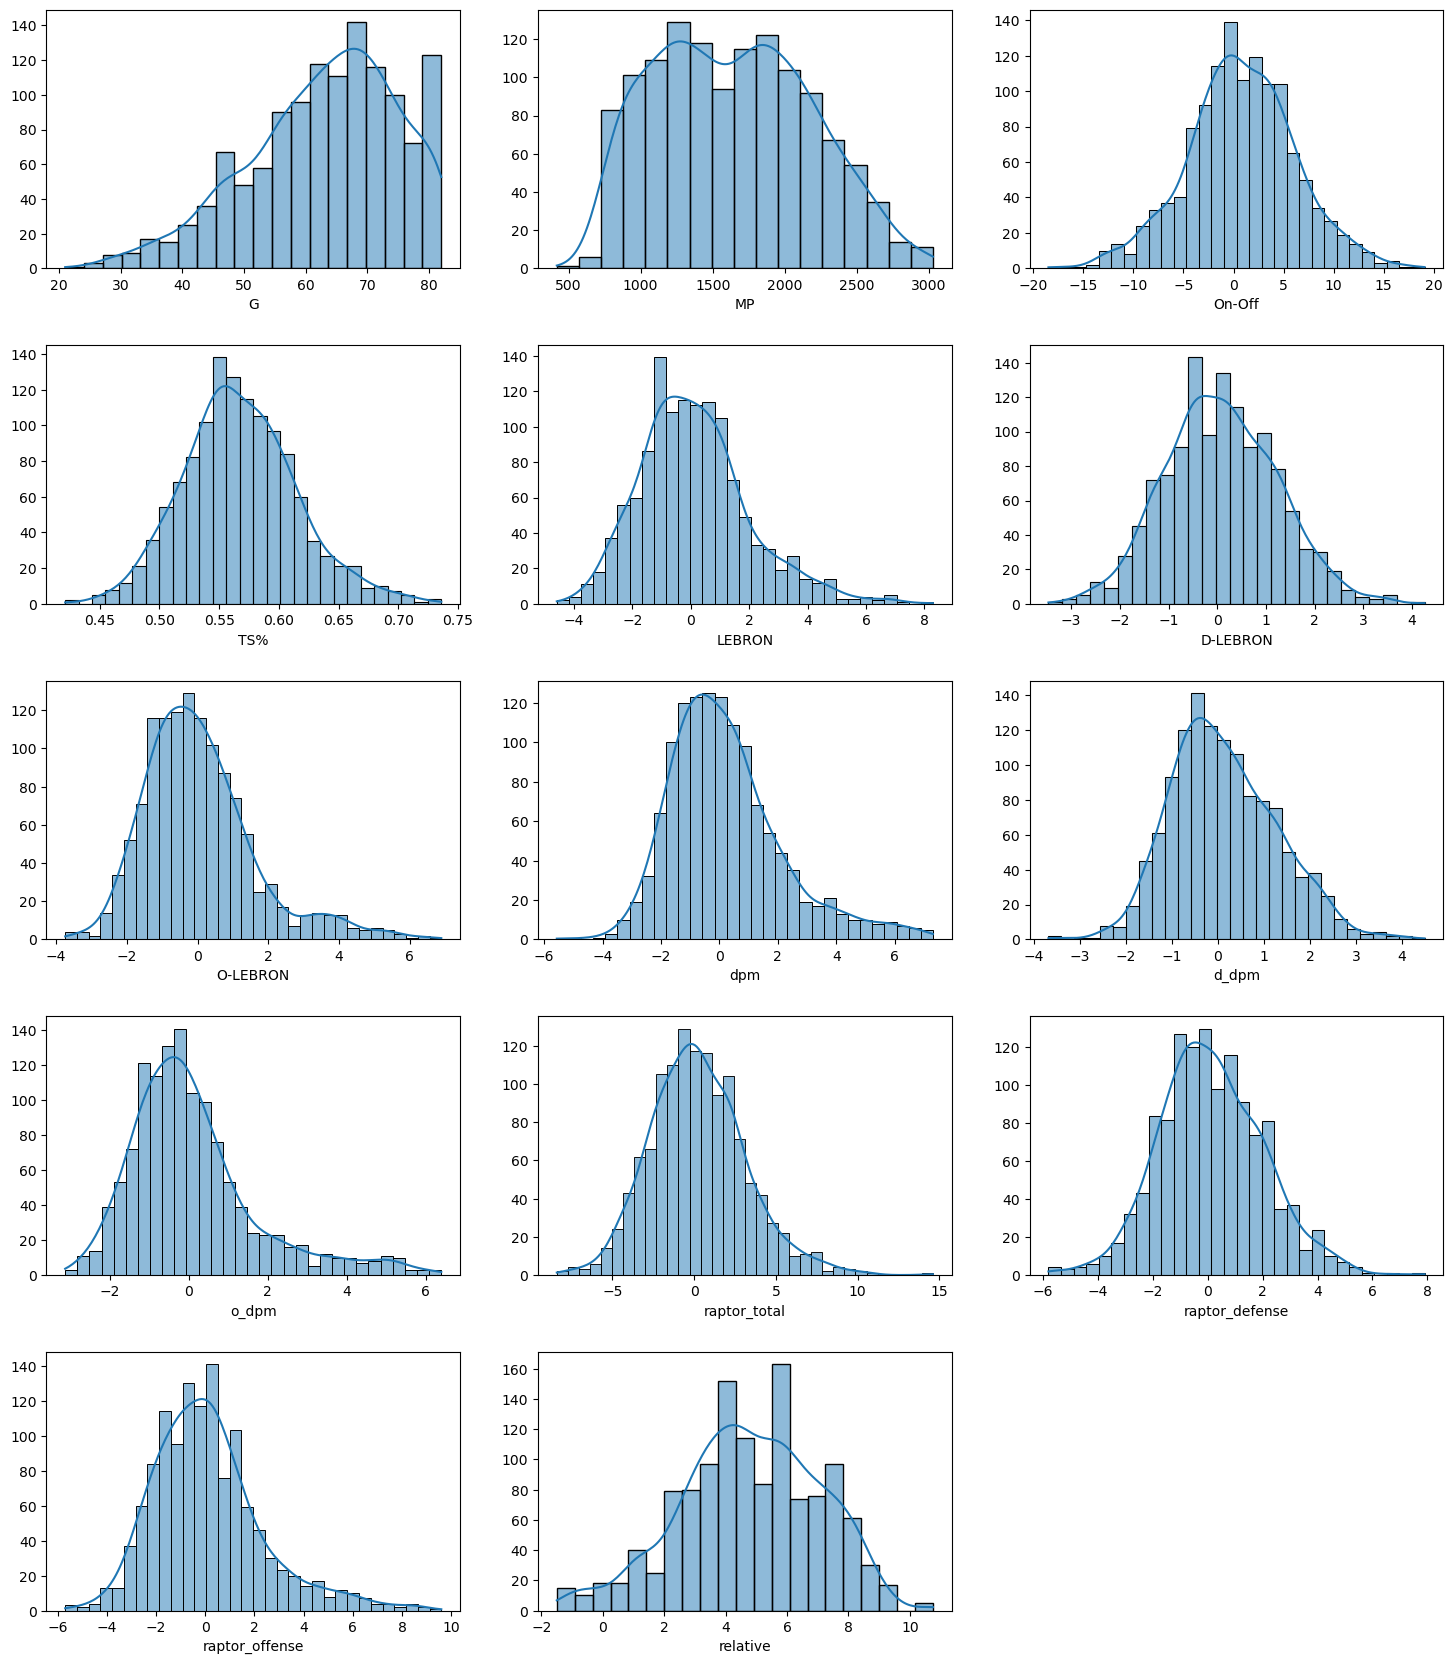

In [33]:
histogram_cols = final_result.columns.tolist()
#print(histogram_cols)
keep = ['G', 'MP', 'On-Off', 'TS%', 'LEBRON', 'D-LEBRON', 'O-LEBRON', 'dpm', 'd_dpm', 'o_dpm', 'raptor_total', 'raptor_defense', 'raptor_offense', 'relative']
#print(len(keep))
histogram_df = final_result[keep]

fig,axes = plt.subplots(5, 3, figsize=(15,17))
axes = axes.flatten()

for i, col in enumerate(keep):
    sns.histplot(data=histogram_df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')
    axes[i].set_title('')

plt.tight_layout(pad=2)
axes[-1].axis('off')

##### Pairplots

Since we are analyzing our relevant variables with a pairplot, we only keep these variables, except for relative. 

In [34]:
features = final_result.columns
features = features.tolist()
remove = ["Player", "Season", "height_inches", "wingspan_inches", "relative", "MP", "G"]
features=[feature for feature in features if feature not in remove]
print(f"Features we are using:\n {features}")
print(f"Number of features:\n {len(features)}")
fr_feature = final_result[features]
fr_feature.head()

Features we are using:
 ['On-Off', 'TS%', 'LEBRON', 'D-LEBRON', 'O-LEBRON', 'dpm', 'd_dpm', 'o_dpm', 'raptor_total', 'raptor_defense', 'raptor_offense']
Number of features:
 11


,On-Off,TS%,LEBRON,D-LEBRON,O-LEBRON,dpm,d_dpm,o_dpm,raptor_total,raptor_defense,raptor_offense
0,9.5,0.627,1.376,1.181,0.195,1.21,0.22,0.99,2.7,0.9,1.8
1,5.8,0.593,0.797,-0.597,1.393,1.13,-0.28,1.40,1.7,-0.0,1.7
2,5.1,0.590,1.265,-1.530,2.794,0.40,-1.23,1.63,1.4,-2.3,3.6
3,13.8,0.578,4.327,0.993,3.334,5.24,0.65,4.59,5.6,1.6,4.0
4,-4.7,0.529,-2.045,-2.011,-0.034,-1.67,-1.25,-0.42,-2.3,-2.4,0.1


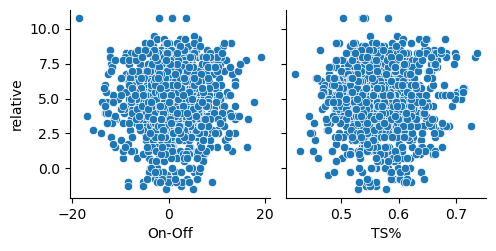

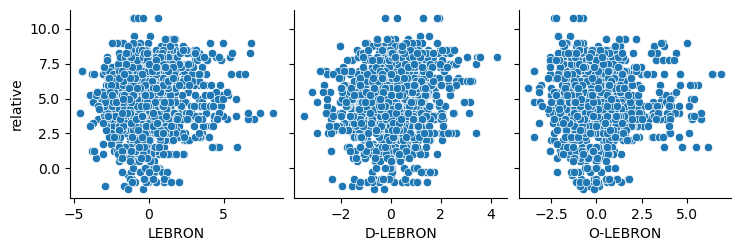

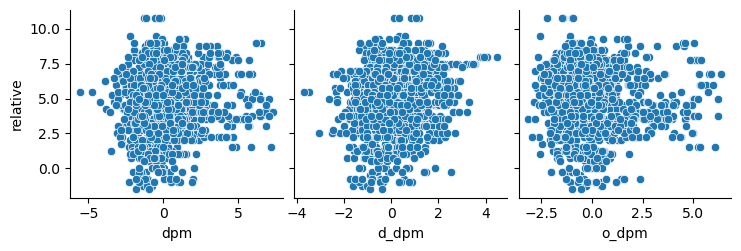

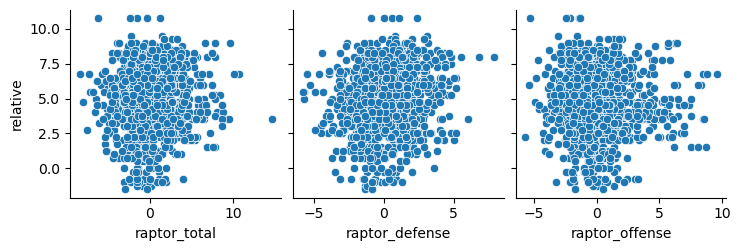

In [35]:
sns.pairplot(final_result, x_vars=features[0:2], y_vars=['relative'])
plt.show()
sns.pairplot(final_result, x_vars=features[2:5], y_vars=['relative'])
plt.show()
sns.pairplot(final_result, x_vars=features[5:8], y_vars=['relative'])
plt.show()
sns.pairplot(final_result, x_vars=features[8:11], y_vars=['relative'])
plt.show()

From the visualizations of our pairplots, we can see that most of the time, there isn't really an association between relative wingspan and our advanced metrics. The extreme outliers in wingspan don't tend to excel in any of the advanced stats, and the positive outliers in each advanced metric seem to occur without a correlation with relative wingspan. 

##### Scatterplots

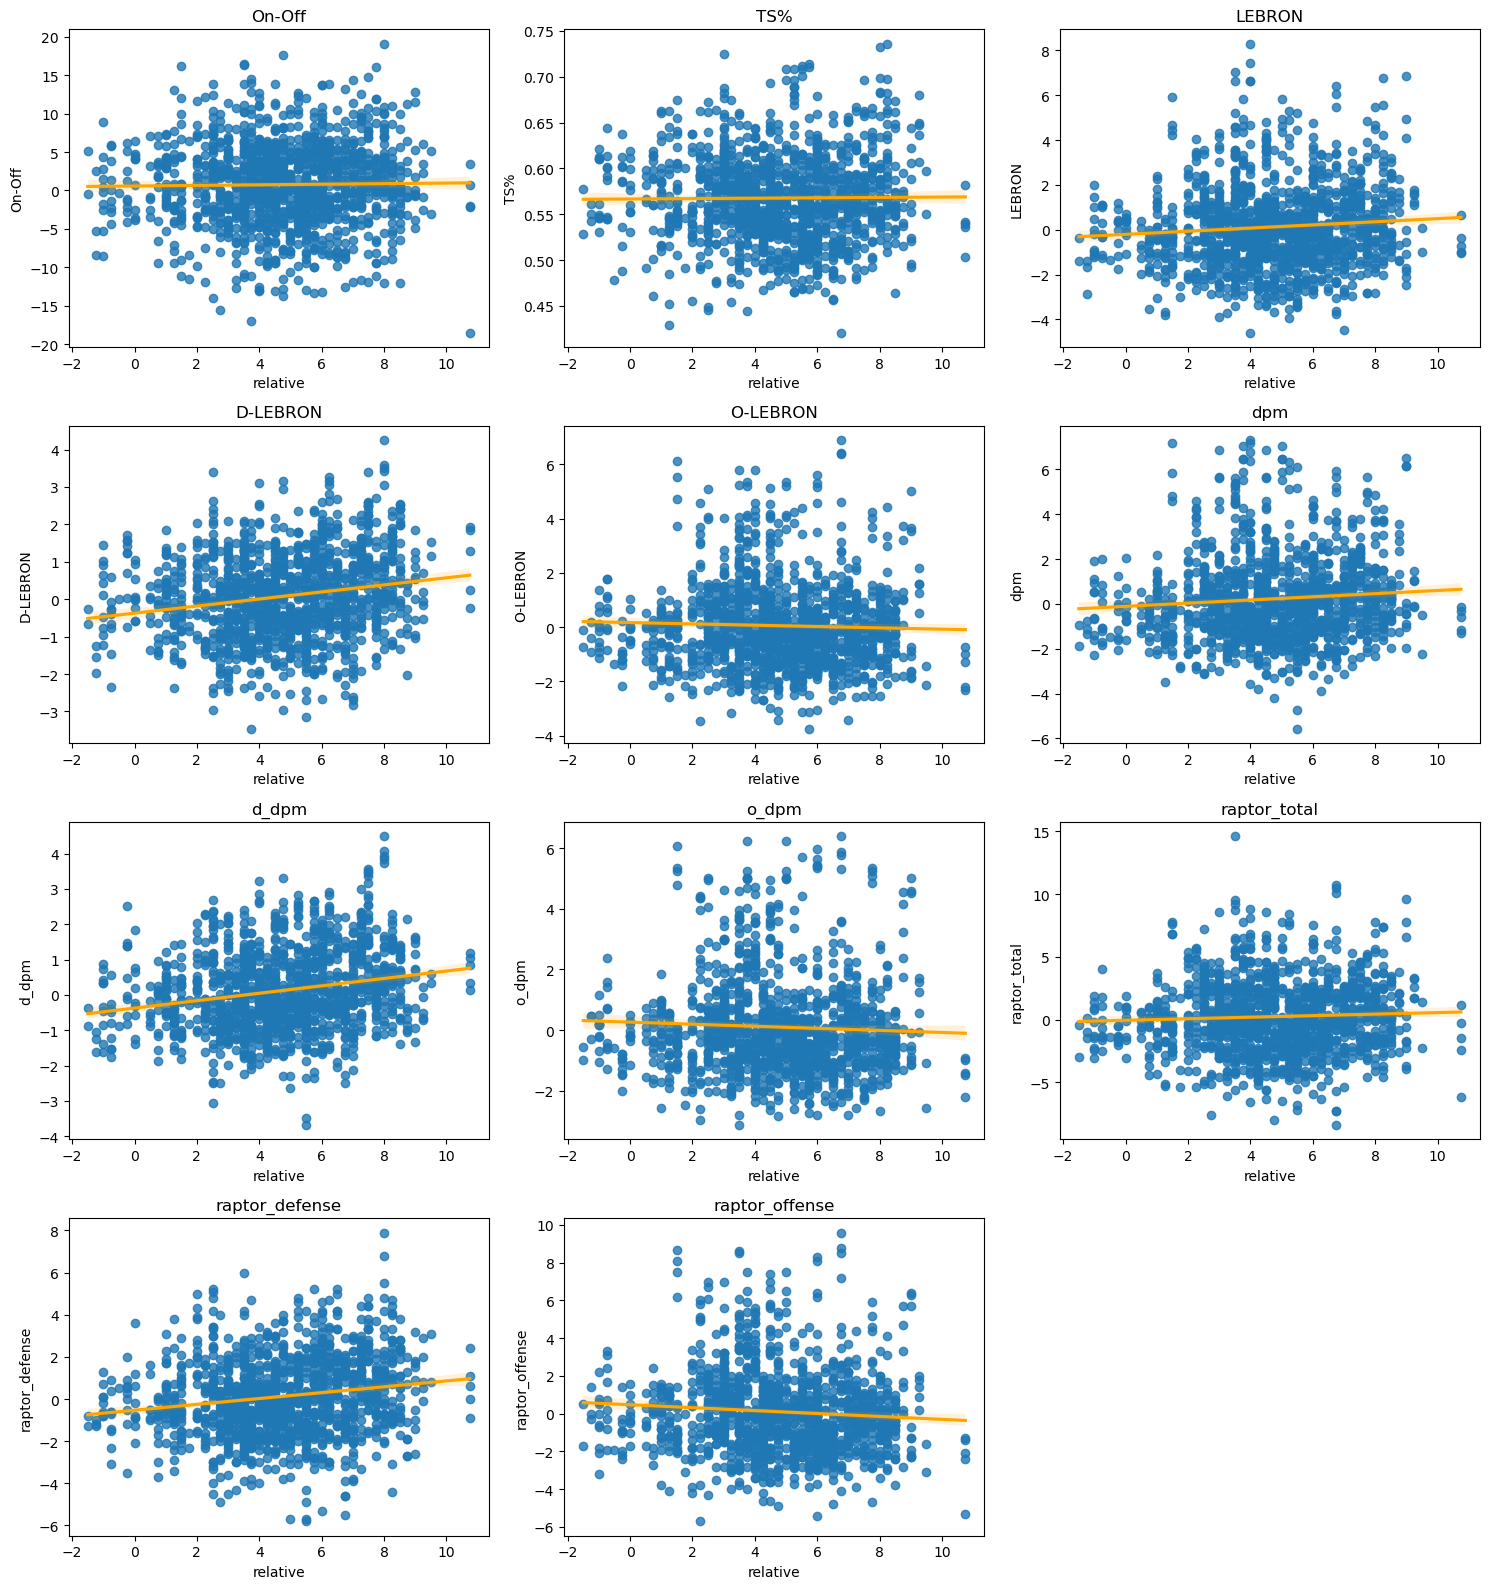

In [36]:
plots_per_row = 3
n_rows = (len(features) + plots_per_row - 1) // plots_per_row
fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(plots_per_row*5, n_rows*4))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.regplot(data=final_result, x="relative", y=feature, ax=axes[i], line_kws={"color": "orange"})
    axes[i].set_title(feature)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Building off of the pairplots from earlier, we can see that after adding a line of best fit with these scatter plots, we can see that there is a slight correlation between net LEBRON, RAPTOR and DARKO. As predicted in our hypothesis, relative wingpsan actually correlates positively with defensive metrics, such as D-LEBRON, d_dpm and raptor_defense, and there is a weaker, negative correlation with offensive metrics such as O-LEBRON, o_dpm and raptor-offense. The negatives from offensive stats and positives from defensive stats balance out because the aggregate is just the sum of the offensive and defensive sub-parts. Therefore, there is a smaller correlation with the aggregate stat. Lastly, there is not really a strong correlation between both On-Off and True Shooting with relative wingspan, surprisingly enough.

In [37]:
fr_relative_corr = final_result[features + ['relative']].corr()['relative'].drop('relative')
fr_relative_corr

On-Off            0.015998
TS%               0.009926
LEBRON            0.084540
D-LEBRON          0.187045
O-LEBRON         -0.034917
dpm               0.082430
d_dpm             0.207897
o_dpm            -0.047557
raptor_total      0.047535
raptor_defense    0.166956
raptor_offense   -0.077583
Name: relative, dtype: float64

We can see the more precise correlations here, where the offensive metrics are in the 0.15 to 0.2 range, while the defensive metrics are in the -0.03 to -0.08 range. The aggregates range from 0.04 t0 0.08. On-Off and True Shooting are basically 0. 

#### Data Models and Analysis - Analyzing with Math

We will (potentially) show the results from the Spearman and Pearson correlation analysis. We will show the results from the OLS analysis. 

##### OLS

In [38]:
single_relative_model_names = []
single_relative_models = []
for f in features:
    formula = f'Q("{f}") ~ relative'
    model = smf.ols(formula, data=final_result).fit()
    single_relative_models.append(model)
    single_relative_model_names.append(f'{f}_ols')

#table
relative_r_sqr = [] 
relative_p_val = []
relative_coef = []
for model in single_relative_models:
    relative_r_sqr.append(model.rsquared)
    relative_p_val.append(model.pvalues['relative'])
    relative_coef.append(model.params['relative'])
relative_summary = pd.DataFrame({
    'feature': features,
    'correlation': fr_relative_corr[features],
    'coef': relative_coef,
    'r_squared': relative_r_sqr,
    'p_value': relative_p_val
    #add more columns as you may want to
})
relative_summary['p_value'] = relative_summary['p_value'].round(5)
relative_summary.drop(columns=['feature'], inplace=True)

In [39]:
for model, model_name in zip(single_relative_models, single_relative_model_names):
    print('\n')
    print(f'Model name: {model_name}')
    print(model.summary())
    print('-------------------------------------')



Model name: On-Off_ols
                            OLS Regression Results                            
Dep. Variable:            Q("On-Off")   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.3208
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.571
Time:                        21:31:41   Log-Likelihood:                -3898.4
No. Observations:                1255   AIC:                             7801.
Df Residuals:                    1253   BIC:                             7811.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5793      

In [40]:
print(relative_summary.sort_values('correlation', ascending=False).to_string())
print('-------------------------------------')
print(relative_summary.sort_values('coef', ascending=False).to_string())
print('-------------------------------------')
print(relative_summary.sort_values('r_squared', ascending=False).to_string())
print('-------------------------------------')
print(relative_summary.sort_values('p_value', ascending=False).to_string())
print('-------------------------------------')

                correlation      coef  r_squared  p_value
d_dpm              0.207897  0.104840   0.043221  0.00000
D-LEBRON           0.187045  0.094462   0.034986  0.00000
raptor_defense     0.166956  0.139053   0.027874  0.00000
LEBRON             0.084540  0.070103   0.007147  0.00272
dpm                0.082430  0.070754   0.006795  0.00348
raptor_total       0.047535  0.061015   0.002260  0.09233
On-Off             0.015998  0.038178   0.000256  0.57124
TS%                0.009926  0.000209   0.000099  0.72538
O-LEBRON          -0.034917 -0.024359   0.001219  0.21641
o_dpm             -0.047557 -0.034058   0.002262  0.09218
raptor_offense    -0.077583 -0.077344   0.006019  0.00596
-------------------------------------
                correlation      coef  r_squared  p_value
raptor_defense     0.166956  0.139053   0.027874  0.00000
d_dpm              0.207897  0.104840   0.043221  0.00000
D-LEBRON           0.187045  0.094462   0.034986  0.00000
dpm                0.082430  0.070

#### Conclusion - What did we find? Why?

After modeling with OLS, we can see some results. The coefficient represents the unit increase in the measured metric per unit increase of relative wingspan. As we can see, overall, all of these are very negligible. The R-squared value is also really small. This signifies that our model explains a really small amount of the variation in each measure metric. Essentially, relative wingspan is a really poor predictor of all of these metrics. Lastly, our p-values actually occupy a decently large range, ranging from 0.72 to 0.0. If we use a threshold of p = 0.05, then our observations for raptor-offense, dpm, LEBRON, D-LEBRON, d_dpm and raptor_defense are statistically significant, meaning we can reject our null hypothesis for these specific metrics, meaning, relative wingspan is a really poor predictor for TS%, On-Off, O-LEBRON, raptor_total and o_dpm, and that relative wingspan does have an observable effect on raptor-offense, dpm, LEBRON, D-LEBRON, d_dpm and raptor_defense, but the effect is not really large at all. 

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?


       Yes, they are given informed consent considering that the data is publicly available from an officiated institution. The measurement of select variables such as match performance, height, and wingspan are also a typical practice, and are performed with the players' consent. As these types of characteristics are a core part of the industry, these players would be fully aware of and entirely comprehend the types of data that are being collected in addition to the ways in which they will be used. 


 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?


       Yes, we plan to avoid the possibility of bias by using publicly available data that is grouped on a basis that does not result in any involuntary distinction. Our data will be from sports databases in which all participants, regardless of personal circumstance, are measured. As a result, we are able to retrieve the necessary metrics to perform data analysis on in an unbiased manner.

       
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

        Yes, our analysis relies solely on publicly available professional statistics. We do not collect sensitive personal information beyond physical measurements and performance metrics. Therefore, the risk of exposing private identifiable information is minimal.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

        Yes, linking physical traits to performance may risk reinforcing deterministic interpretations of athletic ability. We emphasize that our results describe statistical associations rather than causal relationships. Additionally, advanced metrics such as RAPTOR and LEBRON rely on modeling assumptions that may embed their own biases.



### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?


       Yes. The data used in this project are publicly available and stored securely on password-protected devices and university-approved platforms. Since we do not collect sensitive personal information, the risk of data breaches is minimal.
       
 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

       Yes. The project relies solely on publicly available professional statistics. Since we do not collect or store private personal information, individuals may request removal through the original data providers rather than through our research.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

       Yes. All data used in this project will be retained only for the duration of the course and deleted after project completion. Because the dataset consists of publicly available professional statistics, no long-term retention of private information is required.


### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

       Yes. We acknowledge that our analysis focuses primarily on measurable physical traits and advanced metrics, which may not fully capture intangible aspects of basketball performance such as leadership or team dynamics. We therefore interpret our findings within the limits of quantitative data and avoid overgeneralizing beyond statistical measures.
       
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

       Yes. We recognize that wingspan data is limited to players who participated in the NBA Draft Combine, which may introduce selection bias. Additionally, omitted variables such as playing style, coaching systems, or team context may confound the relationship between physical traits and performance.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

       Yes. We will present regression results, summary statistics, and visualizations without selectively reporting significant findings. Effect sizes, limitations, and uncertainty measures (e.g., standard errors) will be clearly displayed to avoid overstating conclusions.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

       Yes. Our analysis relies solely on publicly available professional statistics and does not involve sensitive personal information. No private identifiable data will be displayed or analyzed.

       
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

       Yes. All data processing and analysis steps will be documented and reproducible through code. We will clearly document variable definitions, cleaning procedures, and model specifications to ensure transparency and future review.

       
### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

       Yes. Our model relies on physical measurements and performance statistics that are directly related to basketball evaluation. We do not include sensitive demographic variables such as race or socioeconomic status, and we avoid using variables that may serve as proxies for protected characteristics.
       
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

       Yes. Although our study does not focus on demographic group comparisons, we recognize that physical traits may correlate with positional differences. We interpret results cautiously and do not claim fairness implications across demographic groups.

       
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

       Yes. We consider multiple advanced metrics, including composite measures (RAPTOR, LEBRON, DARKO) and efficiency metrics (TS%), to avoid relying on a single definition of performance. This allows us to assess whether the relationship with wingspan is consistent across different measurement frameworks.

       
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

       Yes. We use linear regression models, which allow clear interpretation of coefficients and effect sizes. This enables us to explain how changes in relative wingspan are associated with changes in performance metrics in understandable terms.

       
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

       Yes. We will clearly communicate model limitations, including selection bias, omitted variables, and the non-causal nature of our analysis. This ensures stakeholders understand the scope and boundaries of our findings.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

       Yes. Although this project is conducted for academic purposes and not deployed in production, we will evaluate model robustness through diagnostic checks and sensitivity analysis. Any unexpected results will prompt re-examination of data processing and model specification.
       
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

       Yes. Since this model is used only for academic analysis, it does not directly affect individuals. However, if concerns arise regarding interpretation or misuse, we will revise our analysis and clarify limitations to prevent harm.
       
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

       Yes. Because the model is not deployed in a live production environment, it can be revised or discontinued at any stage. Any issues identified during analysis will result in modification or removal of the model.

       
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

       Yes. We recognize that findings linking physical traits to performance could be misused in scouting or evaluation contexts. We therefore emphasize that our results describe statistical associations and should not be interpreted as deterministic or prescriptive guidelines.

## Team Expectations 

- We will meet at least twice per week in person to ensure steady progress. One meeting will focus on technical work (data cleaning, regression modeling), and the second will focus on writing, interpretation, and revision.

- Before each meeting, assigned members must complete their designated tasks (e.g., coding, variable construction, literature review, formatting). Meetings will be used for problem-solving and integration rather than starting work from scratch.

- We will maintain a shared Google Drive folder and a centralized GitHub repository to ensure full reproducibility of all results. All code will be clearly commented and version-controlled.

- Discord will serve as our primary communication platform. Members are expected to respond within 24 hours, and within 12 hours during the week of submission.

- We will conduct at least one internal review session before submission, where two members independently check the regression outputs and LaTeX tables for accuracy and consistency.

- In case of disagreements, members will first attempt direct discussion. If resolution is not achieved, a third member will mediate. If necessary, we will consult the TA or professor.

## Project Timeline Proposal

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|--------------|-------------|------------------------|------------------|
| 1/28         | 3PM         |          Decided the projects to review              | Discussed project topics, read through project examples, worked on team scheduling and communication. Finished first project review |
| 1/29         | 5PM         |             Looked at the project rubric           | Continued discussing project examples, finished second project review. Submitted form. |
| 2/3          | 4PM         |            Independently brainstormed some project ideas            | Discussed project topic further, considered viability of data collection and analysis. Settled project topic/direction on NBA wingspan. Finished a draft for the project proposal. |
| 2/4          | 6PM         |          Reviewed our project proposal Score| Redid project proposal according to github. |
| 2/15         | 6PM         | Identify and collect datasets related to NBA player wingspan, height, and advanced performance metrics (RAPTOR, LEBRON, DARKO). | Discuss whether the collected datasets contain the necessary variables to study the relationship between relative wingspan and player performance. |
| 2/18         | 6PM         | Clean datasets and standardize player names across sources. Construct the relative wingspan variable and begin merging datasets. | Review data cleaning results and evaluate merge success rate. Confirm that the dataset is ready for exploratory data analysis. |
| 3/4          | 6PM         | Conduct exploratory data analysis (EDA), including examining the distribution of relative wingspan and its relationship with performance metrics. | Discuss patterns identified in EDA and decide which variables and models will be used in the final analysis. |
| 3/10         | 6PM         | Run regression analysis to test the relationship between relative wingspan and performance metrics while controlling for variables such as height and minutes played. | Interpret model results and check robustness using alternative performance metrics. |
| 3/15         | 6PM         | Finalize notebook, visualizations, and written explanations for the project. | Review the entire project to ensure clarity, correctness, and alignment with the research question. |
| 3/18         | Before 11:59 PM | Final edits and prepare submission materials. | Submit Final Project and complete required surveys. |
